### Importing

In [86]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , roc_curve , auc

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Diabetes_risk.csv")
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


### EDA

In [63]:
df.shape

(50000, 41)

In [64]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed', 'Diabetes_Risk'],
      dtype='object')

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        print(f"{col} : {null_count}")

Age : 497
Height_cm : 2945
Weight_kg : 2962
Blood_Glucose : 959
HbA1c : 1974
Total_Cholesterol : 1000
HDL : 1000
LDL : 1000
Triglycerides : 1000
Physical_Activity_Level : 500
Exercise_Hours_Per_Week : 1992
Daily_Walking_Minutes : 1964
Sleep_Hours : 2017
Medication_Adherence : 1000


In [67]:
df = df.dropna()

In [68]:
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
Index: 32679 entries, 0 to 49999
Columns: 41 entries, Patient_ID to Diabetes_Risk
dtypes: float64(17), int64(5), object(19)
memory usage: 10.5+ MB


In [69]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,32679.0,24932.235105,14467.572153,1.0,12348.50,24892.0,37448.5,50000.0
Age,32679.0,54.004774,21.095417,18.0,36.00,54.0,72.0,90.0
Height_cm,32679.0,169.975945,14.463640,145.0,157.50,170.0,182.5,195.0
Weight_kg,32679.0,87.456134,24.509999,45.0,66.40,87.2,108.6,130.0
BMI,32679.0,30.951538,10.317189,11.9,22.80,30.1,37.8,61.7
Waist_Circumference_cm,32679.0,100.030497,23.113671,60.0,80.00,99.9,120.0,140.0
Blood_Glucose,32679.0,159.530503,51.959071,70.0,114.60,159.2,204.6,250.0
HbA1c,32679.0,8.494868,2.310196,4.5,6.50,8.5,10.5,12.5
Fasting_Blood_Sugar,32679.0,142.677867,44.744348,65.0,103.85,142.8,181.7,220.0
Insulin_Level,32679.0,23.510468,12.417792,2.0,12.80,23.5,34.3,45.0


In [70]:
df.describe(include = ["object"]).T.sort_values(by = ["unique"])

,count,unique,top,freq
Hypertension,32679,2,Yes,16535
Residence_Type,32679,2,Urban,16420
PCOS,32679,2,Yes,16358
Fatty_Liver,32679,2,No,16408
Heart_Disease,32679,2,No,16462
Doctor_Consultation_Needed,32679,2,Yes,30367
Family_History_Diabetes,32679,2,Yes,16341
Medication_Adherence,32679,3,Average,10968
Gender,32679,3,Male,10927
Smoking_Status,32679,3,Never,10929


In [71]:
df = df.drop(columns = ["Patient_ID"])

In [72]:
df["Diabetes_Risk"].value_counts()

Diabetes_Risk
High        23925
Moderate     8445
Low           309
Name: count, dtype: int64

### Feature & Target Split

In [73]:
X = df.drop(columns = ["Diabetes_Risk"])
y = df["Diabetes_Risk"]

### Train & Test Split

In [74]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.22 , stratify = y , random_state = 101)

### Model Training

In [78]:
cat_cols = X.select_dtypes(include = ["object"]).columns.tolist()

In [82]:
model = CatBoostClassifier(loss_function = "MultiClass" , iterations = 500 ,
                           learning_rate = 0.05 , depth = 7 ,
                           verbose = 100 , random_seed = 101)
model.fit(X_train , y_train , cat_features = cat_cols)

0:	learn: 1.0027235	total: 304ms	remaining: 2m 31s
100:	learn: 0.0047813	total: 22.9s	remaining: 1m 30s
200:	learn: 0.0001891	total: 46.6s	remaining: 1m 9s
300:	learn: 0.0000851	total: 1m 14s	remaining: 49.4s
400:	learn: 0.0000622	total: 1m 49s	remaining: 27.1s
499:	learn: 0.0000506	total: 2m 16s	remaining: 0us


CatBoostClassifier(depth=7, iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=101, verbose=100)

### Prediction

In [83]:
y_pred = model.predict(X_test)

### Evaluation

In [84]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      5264
         Low       1.00      1.00      1.00        68
    Moderate       1.00      1.00      1.00      1858

    accuracy                           1.00      7190
   macro avg       1.00      1.00      1.00      7190
weighted avg       1.00      1.00      1.00      7190



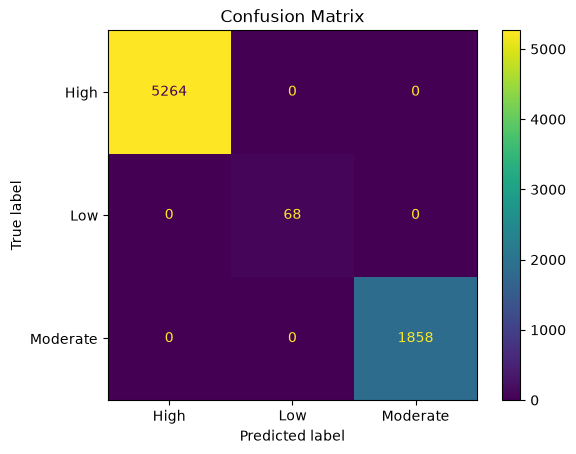

In [85]:
ConfusionMatrixDisplay.from_estimator(estimator = model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

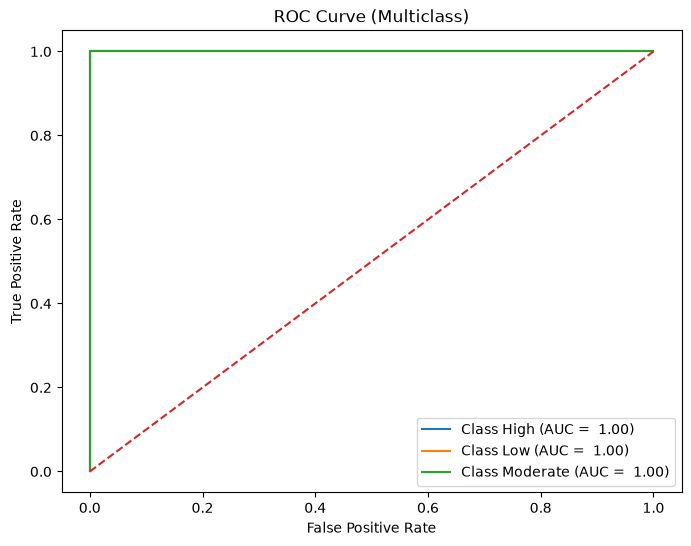

In [87]:
y_score = model.predict_proba(X_test)

classes = model.classes_

y_test_bin = label_binarize(y_test , classes = classes)

plt.figure(figsize = (8 , 6))

for i , cls in enumerate(classes):
    fpr , tpr , _ = roc_curve(y_test_bin[: , i] , y_score[: , i])
    roc_auc = auc(fpr , tpr)
    plt.plot(fpr , tpr , label = f"Class {cls} (AUC = {roc_auc : .2f})")

plt.plot([0 , 1] , [0 , 1] , "--")
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()